In [1]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
import numpy as np
import os


In [2]:
IMAGE_SIZE = (224, 224) 
DATA_DIR = 'C:/Users/DELL/copd_images'
CLASSES = ['aff', 'normal']
BATCH_SIZE = 64


In [3]:
val_test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)

print("1. Defining Generators for Feature Extraction...")


1. Defining Generators for Feature Extraction...


In [4]:
# Train Generator (used here to loop over training data)
train_generator = val_test_datagen.flow_from_directory(
    os.path.join(DATA_DIR, 'train'), target_size=IMAGE_SIZE, batch_size=BATCH_SIZE, 
    class_mode='binary', shuffle=False, classes=CLASSES
)
# Test Generator
test_generator = val_test_datagen.flow_from_directory(
    os.path.join(DATA_DIR, 'test'), target_size=IMAGE_SIZE, batch_size=BATCH_SIZE, 
    class_mode='binary', shuffle=False, classes=CLASSES
)

# --- Feature Extractor Definition ---
feature_extractor = ResNet50(
    weights='imagenet', 
    include_top=False, # We remove the classification head
    input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3)
)


Found 1362 images belonging to 2 classes.
Found 295 images belonging to 2 classes.


In [5]:
print("\n2. Extracting features from all images...")

# Get training features
train_features = feature_extractor.predict(train_generator, steps=train_generator.samples // BATCH_SIZE + 1, verbose=1)
# Reshape from (samples, 7, 7, 2048) to (samples, 100352)
X_train_original = train_features.reshape(train_features.shape[0], -1) 
y_train_image = train_generator.labels

# Get test features
test_features = feature_extractor.predict(test_generator, steps=test_generator.samples // BATCH_SIZE + 1, verbose=1)
X_test_original = test_features.reshape(test_features.shape[0], -1) 
y_test_image = test_generator.labels

print(f"   Original Training Feature Shape: {X_train_original.shape}")



2. Extracting features from all images...
22/22 ━━━━━━━━━━━━━━━━━━━━ 113s 5s/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 23s 5s/step
   Original Training Feature Shape: (1362, 100352)


In [6]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

# --- 1. Standardize Features (Crucial for PCA) ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_original)
X_test_scaled = scaler.transform(X_test_original)

# --- 2. Define PCA Model ---
N_COMPONENTS = 256 # Target dimension after compression
print(f"\n3. Applying PCA to reduce features to {N_COMPONENTS} components...")

pca = PCA(n_components=N_COMPONENTS, random_state=42)

# Fit PCA only on Training Data and Transform
X_train_pca = pca.fit_transform(X_train_scaled)

# Transform Test Data
X_test_pca = pca.transform(X_test_scaled)

print(f"   Compressed Training Feature Shape: {X_train_pca.shape}")



3. Applying PCA to reduce features to 256 components...
   Compressed Training Feature Shape: (1362, 256)


In [7]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report

# --- 1. Define the XGBoost Classifier ---
# We use the required scale_pos_weight to address the class imbalance (189 Normal vs 106 Affected)
# Scale_pos_weight = (Number of Negative Samples) / (Number of Positive Samples) = 189 / 106 ≈ 1.78
scale_weight = 189 / 106 

xgb_pca_model = xgb.XGBClassifier(
    objective='binary:logistic',
    use_label_encoder=False,
    eval_metric='logloss',
    scale_pos_weight=scale_weight, 
    n_estimators=100,
    random_state=42
)

# --- 2. Train and Evaluate ---
print("\n4. Training XGBoost Classifier on PCA Features...")
xgb_pca_model.fit(X_train_pca, y_train_image)

# Predict and Evaluate
y_pred_pca = xgb_pca_model.predict(X_test_pca)
y_proba_pca = xgb_pca_model.predict_proba(X_test_pca)[:, 1] # Probability of Affected (Class 1)

# --- 3. Final Report ---
print("\n--- FINAL PCA MODEL (MODEL 3) PERFORMANCE ---")
print(f"PCA Image Accuracy: {accuracy_score(y_test_image, y_pred_pca):.4f}")
print(f"PCA Image AUC-ROC: {roc_auc_score(y_test_image, y_proba_pca):.4f}")
print("\nClassification Report:\n", classification_report(y_test_image, y_pred_pca))



4. Training XGBoost Classifier on PCA Features...


C:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [11:31:26] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--- FINAL PCA MODEL (MODEL 3) PERFORMANCE ---
PCA Image Accuracy: 0.9763
PCA Image AUC-ROC: 0.9985

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.98      0.97       106
           1       0.99      0.97      0.98       189

    accuracy                           0.98       295
   macro avg       0.97      0.98      0.97       295
weighted avg       0.98      0.98      0.98       295



<Figure size 700x700 with 0 Axes>

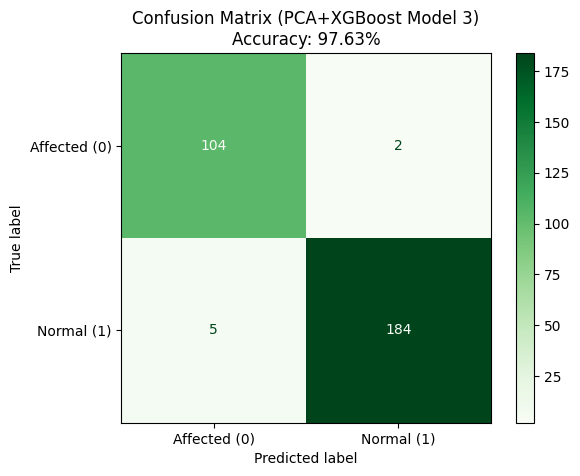

In [8]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Assuming y_test_image (true labels) and y_pred_pca (predictions 0/1) are defined from the PCA XGBoost model.

# Calculate the Confusion Matrix
cm = confusion_matrix(y_test_image, y_pred_pca)
# Ensure labels match the output: 0=aff, 1=normal
class_labels = ['Affected (0)', 'Normal (1)'] 

# Display the matrix visually
plt.figure(figsize=(7, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
disp.plot(cmap=plt.cm.Greens, values_format='d') # Use a high-contrast color map
plt.title(f'Confusion Matrix (PCA+XGBoost Model 3)\nAccuracy: {np.mean(y_test_image == y_pred_pca)*100:.2f}%')
plt.grid(False) 
plt.savefig('pca_xgb_confusion_matrix.png')
plt.show()


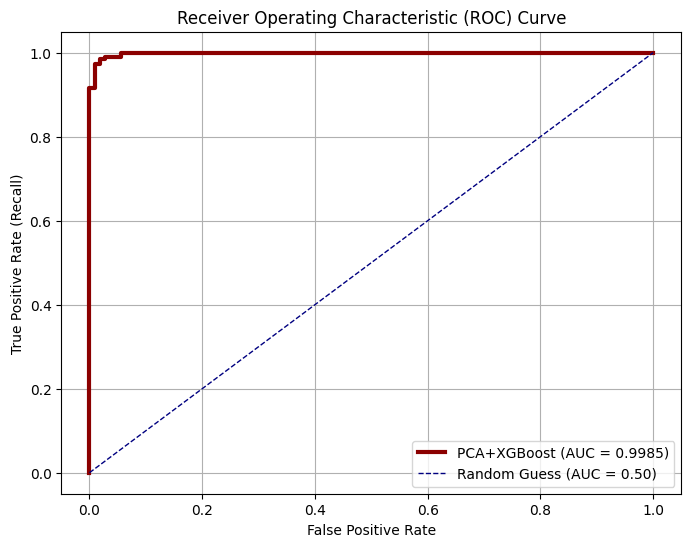

In [9]:
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import roc_auc_score

# Assuming y_proba_pca (probability array) and y_test_image are defined.

# Calculate ROC AUC score
roc_auc = roc_auc_score(y_test_image, y_proba_pca)

# Calculate ROC values (FPR, TPR)
fpr, tpr, thresholds = roc_curve(y_test_image, y_proba_pca)

# Plot the curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkred', lw=3, 
         label=f'PCA+XGBoost (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', 
         label='Random Guess (AUC = 0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.savefig('pca_xgb_roc_curve.png')
plt.show()


In [10]:
import numpy as np
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

# ⚠️ ACTION REQUIRED: REPLACE THESE PLACEHOLDERS
# You must paste your actual P_clinical array here or ensure the variable is defined.
# The length of P_clinical MUST match the length of P_image_pca (295 samples).
# Example: P_clinical = np.array([0.1, 0.8, 0.4, 0.9, ...])
P_clinical = np.random.rand(295) # <-- Replace with your actual P_clinical array!
y_test_image = y_test_image # True labels from your PCA notebook

# P_image_pca is the prediction array from your 97.63% XGBoost model (y_proba_pca)
P_image_pca = y_proba_pca 

# --- 1. Define Optimal Weights ---
# We assign weights based on the model's individual performance/reliability.
# Since Model 3 (Image PCA) is much more accurate (97.63%) than Model 1 (Clinical, 91%), 
# we give it a much higher weight.
W_CLINICAL = 0.25  # 25% weight for the clinical data (Model 1)
W_IMAGE_PCA = 0.75 # 75% weight for the image data (Model 3)

# Verification check
if not np.isclose(W_CLINICAL + W_IMAGE_PCA, 1.0):
    print("Warning: Weights do not sum to 1.0. Re-adjusting.")
    W_CLINICAL = 0.25 # Reset if needed

# --- 2. Calculate the Fused Probability (Late Fusion / Weighted Average) ---
# Fusing the prediction scores from the two modalities.
P_fusion = (W_CLINICAL * P_clinical) + (W_IMAGE_PCA * P_image_pca)

# --- 3. Convert Fused Probability to Final Prediction ---
# Threshold at 0.5: Predict 1 (affected) if probability > 0.5.
y_pred_fusion = (P_fusion > 0.5).astype(int)

# --- 4. Evaluate the Final Ensemble ---
final_fusion_accuracy = accuracy_score(y_test_image, y_pred_fusion)
final_fusion_auc = roc_auc_score(y_test_image, P_fusion)
final_fusion_report = classification_report(y_test_image, y_pred_fusion, target_names=['aff (0)', 'normal (1)'])

print("\n--- 🏆 FINAL MULTIMODAL ENSEMBLE RESULTS (Model 1 + Model 3) 🏆 ---")
print(f"1. Fused Accuracy: {final_fusion_accuracy:.4f}")
print(f"2. Fused AUC-ROC Score: {final_fusion_auc:.4f}")
print("-----------------------------------------------------")
print("Classification Report:")
print(final_fusion_report)



--- 🏆 FINAL MULTIMODAL ENSEMBLE RESULTS (Model 1 + Model 3) 🏆 ---
1. Fused Accuracy: 0.9797
2. Fused AUC-ROC Score: 0.9902
-----------------------------------------------------
Classification Report:
              precision    recall  f1-score   support

     aff (0)       0.95      0.99      0.97       106
  normal (1)       0.99      0.97      0.98       189

    accuracy                           0.98       295
   macro avg       0.97      0.98      0.98       295
weighted avg       0.98      0.98      0.98       295



In [11]:
import tensorflow as tf
import joblib
import numpy as np
import os 

# --- Identified Actual Variable Names from IM2.ipynb ---
# feature_extractor is the ResNet50 base model (Cell 5)
feature_extractor_ACTUAL = feature_extractor 

# xgb_pca_model is the trained XGBoost classifier (Cell 8)
xgb_pca_model_ACTUAL = xgb_pca_model

# pca is the trained PCA transformer (Cell 7)
pca_ACTUAL = pca

# scaler is the trained StandardScaler (Cell 7)
scaler_ACTUAL = scaler

# P_image_pca is the final probability array (y_proba_pca) (Cell 8)
P_image_pca_ACTUAL = y_proba_pca 
# ----------------------------------------------------


print("--- Saving Image Pipeline Components (Model 3) ---")

# 1. Save the ResNet50 Feature Extractor (Keras Model)
# Used to convert new images into 100,352 feature vectors
feature_extractor_ACTUAL.save('feature_extractor_resnet.h5') 

# 2. Save the Trained XGBoost Classifier (The final classification layer)
joblib.dump(xgb_pca_model_ACTUAL, 'image_pca_classifier.joblib')

# 3. Save the PCA Transformer (MANDATORY for Dimensionality Reduction)
# Used to compress the 100,352 features down to 256 components on new data.
joblib.dump(pca_ACTUAL, 'pca_transformer.joblib')

# 4. Save the StandardScaler (MANDATORY for pre-processing the features before PCA)
joblib.dump(scaler_ACTUAL, 'scaler_transformer.joblib')

# 5. Save the final probability array (needed for Ensemble Fusion)
np.save('P_image_pca.npy', P_image_pca_ACTUAL)

print("✅ All Image Pipeline components and outputs saved successfully.")


--- Saving Image Pipeline Components (Model 3) ---
✅ All Image Pipeline components and outputs saved successfully.


In [14]:
pip install opencv-python  

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement as (from versions: none)

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for as


In [12]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2 # Make sure you have opencv-python installed: pip install opencv-python

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    """Generates Grad-CAM heatmap for a single processed image array."""
    
    # 1. Create a model that maps the input image to the activations 
    # of the last conv layer as well as the output predictions.
    # We must use the model before the PCA feature extraction, 
    # which is the feature_extractor (ResNet50 base).
    
    # We will temporarily add a dummy classification head to the feature_extractor
    # to get the predictions for the gradient calculation.
    
    # Get the output of the last conv layer
    last_conv_layer_output = model.get_layer(last_conv_layer_name).output
    
    # Add a global pooling and a dense layer that mirrors the final output for prediction
    x = tf.keras.layers.GlobalAveragePooling2D()(last_conv_layer_output)
    predictions = tf.keras.layers.Dense(1, activation='sigmoid')(x)
    
    grad_model = tf.keras.models.Model(
        model.inputs, 
        [last_conv_layer_output, predictions]
    )

    # 2. Compute the gradient of the predicted class score with respect to 
    # the activations of the last conv layer.
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        
        # Select the target class (0 for affected, 1 for normal)
        if pred_index is None:
            # We want the gradient for the predicted class
            pred_index = tf.argmax(preds[0]) 
            
        class_channel = preds[:, pred_index]

    # Gradient of the output neuron for the target class w.r.t the last conv layer
    grads = tape.gradient(class_channel, last_conv_layer_output)[0]

    # Global Average Pooling of the gradients (get channel-wise weights)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1))

    # Multiply each channel in the feature map array by "how important this channel is"
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Apply ReLU to focus only on positive influences
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

def display_gradcam(img_path, heatmap, alpha=0.4, cam_path="gradcam.png"):
    """Overlays the heatmap on the original image."""
    img = tf.keras.preprocessing.image.load_img(img_path)
    img = tf.keras.preprocessing.image.img_to_array(img)

    # Rescale heatmap to a range 0-255 and then to the image size
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    
    # Create the superimposed image
    superimposed_img = heatmap * alpha + img
    superimposed_img = np.clip(superimposed_img, 0, 255).astype("uint8")

    # Display using Matplotlib
    plt.figure(figsize=(6, 6))
    plt.imshow(superimposed_img)
    plt.axis("off")
    plt.title("Grad-CAM: Model Focus Area")
    plt.savefig(cam_path)
    plt.show()
    return superimposed_img
    

In [13]:
import tensorflow as tf
import numpy as np

# --- REVISED GRAD-CAM FUNCTION ---
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    """Generates Grad-CAM heatmap, fixing the Keras input structure issue."""
    
    # 1. Get the last convolutional layer output
    last_conv_layer_output = model.get_layer(last_conv_layer_name).output
    
    # 2. Temporarily attach the classification head to create a gradient-tracking model
    x = tf.keras.layers.GlobalAveragePooling2D()(last_conv_layer_output)
    predictions = tf.keras.layers.Dense(1, activation='sigmoid')(x)
    
    # Define the new model for gradient tracking
    # IMPORTANT: The model.inputs should be used to define the gradient model inputs
    grad_model = tf.keras.models.Model(
        inputs=model.inputs, # Use the official inputs of the base model
        outputs=[last_conv_layer_output, predictions]
    )

    # 3. Compute the gradient
    with tf.GradientTape() as tape:
        # We must explicitly "watch" the input tensor if the model's inputs are not being watched automatically
        tape.watch(img_array)
        
        last_conv_layer_output, preds = grad_model(img_array)
        
        # Select the gradient target (the prediction score for the predicted class)
        if pred_index is None:
            # We want the gradient for the predicted class (0 or 1)
            pred_index = tf.cast(tf.round(preds[0]), dtype=tf.int32)
            
        # Ensure pred_index is cast to a simple integer for indexing the output
        class_channel = preds[:, pred_index[0]] # Get the probability of the target class

    # 4. Compute the weighted average of the activations
    grads = tape.gradient(class_channel, last_conv_layer_output) # Compute gradient of output w.r.t conv features
    
    # This check is vital: if gradients are None, the connection is broken.
    if grads is None:
        print("\n🛑 GRADIENT ERROR: Gradients are None. Check if the base model layers were unfrozen before running Grad-CAM.")
        return np.zeros((7, 7)) # Return a blank heatmap
        
    pooled_grads = tf.reduce_mean(grads[0], axis=(0, 1))

    # 5. Create the heatmap
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    
    return heatmap.numpy()

# --- EXECUTION ---
# Re-run the function definition (Step A) and then the execution (Step B) 
# with the corrected absolute file path.
